In [ ]:
!pip install pyspark

In [ ]:
import pyspark

In [ ]:
from pyspark.sql import SparkSession

In [ ]:
spark = SparkSession.builder.appName('Dataframe').getOrCreate()

In [ ]:
df_pyspark = spark.read.option('header','true').csv('/content/drive/MyDrive/Colab Notebooks/data/test1.csv')

In [ ]:
df_pyspark.show()

+--------+---+------+----------+------------------+--------------+----+----+---+
|Match_ID|Div|Season|      Date|          HomeTeam|      AwayTeam|FTHG|FTAG|FTR|
+--------+---+------+----------+------------------+--------------+----+----+---+
|       1| D2|  2009|2010-04-04|        Oberhausen|Kaiserslautern|   2|   1|  H|
|       2| D2|  2009|2009-11-01|       Munich 1860|Kaiserslautern|   0|   1|  A|
|       3| D2|  2009|2009-10-04|     Frankfurt FSV|Kaiserslautern|   1|   1|  D|
|       4| D2|  2009|2010-02-21|     Frankfurt FSV|     Karlsruhe|   2|   1|  H|
|       5| D2|  2009|2009-12-06|             Ahlen|     Karlsruhe|   1|   3|  A|
|       6| D2|  2009|2010-04-03|      Union Berlin|     Karlsruhe|   1|   1|  D|
|       7| D2|  2009|2009-08-14|         Paderborn|     Karlsruhe|   2|   0|  H|
|       8| D2|  2009|2010-03-08|         Bielefeld|     Karlsruhe|   0|   1|  A|
|       9| D2|  2009|2009-09-26|    Kaiserslautern|     Karlsruhe|   2|   0|  H|
|      10| D2|  2009|2009-11

In [ ]:
df_pyspark.printSchema()

root
 |-- Match_ID: string (nullable = true)
 |-- Div: string (nullable = true)
 |-- Season: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- HomeTeam: string (nullable = true)
 |-- AwayTeam: string (nullable = true)
 |-- FTHG: string (nullable = true)
 |-- FTAG: string (nullable = true)
 |-- FTR: string (nullable = true)



In [ ]:
from pyspark.sql.functions import col

df = df_pyspark.withColumn(
    "Season", col("Season").cast("int")
).withColumn(
    "FTHG", col("FTHG").cast("int")
).withColumn(
    "FTAG", col("FTAG").cast("int")
)

In [ ]:
df.printSchema()

root
 |-- Match_ID: string (nullable = true)
 |-- Div: string (nullable = true)
 |-- Season: integer (nullable = true)
 |-- Date: string (nullable = true)
 |-- HomeTeam: string (nullable = true)
 |-- AwayTeam: string (nullable = true)
 |-- FTHG: integer (nullable = true)
 |-- FTAG: integer (nullable = true)
 |-- FTR: string (nullable = true)



In [ ]:
df = df_pyspark.select(
    "Match_ID",
    "Div",
    "Season",
    "HomeTeam",
    "AwayTeam",
    "FTHG",
    "FTAG",
    "FTR"
)

df = df.dropna()

In [ ]:
df = df.withColumnRenamed("FTHG", "HomeGoals") \
       .withColumnRenamed("FTAG", "AwayGoals") \
       .withColumnRenamed("FTR", "Result")

In [ ]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    "HomeTeamWin",
    when(col("Result") == "H", 1).otherwise(0)
)

df = df.withColumn(
    "AwayTeamWin",
    when(col("Result") == "A", 1).otherwise(0)
)

df = df.withColumn(
    "GameTie",
    when(col("Result") == "D", 1).otherwise(0)
)

In [ ]:
df.show()

+--------+---+------+------------------+--------------+---------+---------+------+-----------+-----------+-------+
|Match_ID|Div|Season|          HomeTeam|      AwayTeam|HomeGoals|AwayGoals|Result|HomeTeamWin|AwayTeamWin|GameTie|
+--------+---+------+------------------+--------------+---------+---------+------+-----------+-----------+-------+
|       1| D2|  2009|        Oberhausen|Kaiserslautern|        2|        1|     H|          1|          0|      0|
|       2| D2|  2009|       Munich 1860|Kaiserslautern|        0|        1|     A|          0|          1|      0|
|       3| D2|  2009|     Frankfurt FSV|Kaiserslautern|        1|        1|     D|          0|          0|      1|
|       4| D2|  2009|     Frankfurt FSV|     Karlsruhe|        2|        1|     H|          1|          0|      0|
|       5| D2|  2009|             Ahlen|     Karlsruhe|        1|        3|     A|          0|          1|      0|
|       6| D2|  2009|      Union Berlin|     Karlsruhe|        1|        1|     

In [ ]:
df = df.filter(col("Div") == "D1")

df = df.filter(
    (col("Season") >= 2000) &
    (col("Season") <= 2015)
)

In [ ]:
from pyspark.sql.functions import *
# agg() → calculates summary statistics
df_home_matches = df.groupBy("Season", "HomeTeam").agg(

    count("*").alias("HomeGames"),

    sum("HomeGoals").alias("HomeGoalsScored"),

    sum("AwayGoals").alias("HomeGoalsAgainst"),

    sum("HomeTeamWin").alias("HomeWins"),

    sum("AwayTeamWin").alias("HomeLosses"),

    sum("GameTie").alias("HomeTies")
)

df_home_matches.show()

+------+--------------+---------+---------------+----------------+--------+----------+--------+
|Season|      HomeTeam|HomeGames|HomeGoalsScored|HomeGoalsAgainst|HomeWins|HomeLosses|HomeTies|
+------+--------------+---------+---------------+----------------+--------+----------+--------+
|  2011|       Hamburg|       17|           19.0|            29.0|       3|         7|       7|
|  2005|Kaiserslautern|       17|           26.0|            33.0|       5|         7|       5|
|  2006|       Cottbus|       17|           21.0|            22.0|       6|         6|       5|
|  2001|      St Pauli|       17|           19.0|            28.0|       4|         9|       4|
|  2005|         Mainz|       17|           31.0|            23.0|       6|         4|       7|
|  2006|       Hamburg|       17|           22.0|            19.0|       4|         4|       9|
|  2003|     Stuttgart|       17|           29.0|            13.0|       9|         1|       7|
|  2015|        Hertha|       17|       

In [ ]:
df_away_matches = df.groupBy("Season", "AwayTeam").agg(

    count("*").alias("AwayGames"),

    sum("AwayGoals").alias("AwayGoalsScored"),

    sum("HomeGoals").alias("AwayGoalsAgainst"),

    sum("AwayTeamWin").alias("AwayWins"),

    sum("HomeTeamWin").alias("AwayLosses"),

    sum("GameTie").alias("AwayTies")
)

df_away_matches.show()

+------+--------------+---------+---------------+----------------+--------+----------+--------+
|Season|      AwayTeam|AwayGames|AwayGoalsScored|AwayGoalsAgainst|AwayWins|AwayLosses|AwayTies|
+------+--------------+---------+---------------+----------------+--------+----------+--------+
|  2011|       Hamburg|       17|           16.0|            28.0|       5|         7|       5|
|  2005|Kaiserslautern|       17|           21.0|            38.0|       3|        10|       4|
|  2006|       Cottbus|       17|           17.0|            27.0|       5|         9|       3|
|  2001|      St Pauli|       17|           18.0|            42.0|       0|        11|       6|
|  2005|         Mainz|       17|           15.0|            24.0|       3|        10|       4|
|  2006|       Hamburg|       17|           21.0|            18.0|       6|         5|       6|
|  2003|     Stuttgart|       17|           23.0|            11.0|       9|         5|       3|
|  2015|        Hertha|       17|       

In [ ]:
from pyspark.sql.functions import col

# rename columns so both tables match
df_home_matches = df_home_matches.withColumnRenamed("HomeTeam", "Team")
df_away_matches = df_away_matches.withColumnRenamed("AwayTeam", "Team")

# join both DataFrames
df_merged = df_home_matches.join(
    df_away_matches,
    on=["Season", "Team"],
    how="inner"
)

# show result
df_merged.show()

+------+--------------+---------+---------------+----------------+--------+----------+--------+---------+---------------+----------------+--------+----------+--------+
|Season|          Team|HomeGames|HomeGoalsScored|HomeGoalsAgainst|HomeWins|HomeLosses|HomeTies|AwayGames|AwayGoalsScored|AwayGoalsAgainst|AwayWins|AwayLosses|AwayTies|
+------+--------------+---------+---------------+----------------+--------+----------+--------+---------+---------------+----------------+--------+----------+--------+
|  2011|       Hamburg|       17|           19.0|            29.0|       3|         7|       7|       17|           16.0|            28.0|       5|         7|       5|
|  2005|Kaiserslautern|       17|           26.0|            33.0|       5|         7|       5|       17|           21.0|            38.0|       3|        10|       4|
|  2006|       Cottbus|       17|           21.0|            22.0|       6|         6|       5|       17|           17.0|            27.0|       5|         9|  

In [ ]:

df_final = df_merged.withColumn(
    "GoalsScored",
    col("HomeGoalsScored") + col("AwayGoalsScored")
).withColumn(
    "GoalsAgainst",
    col("HomeGoalsAgainst") + col("AwayGoalsAgainst")
).withColumn(
    "Win",
    col("HomeWins") + col("AwayWins")
).withColumn(
    "Loss",
    col("HomeLosses") + col("AwayLosses")
).withColumn(
    "Tie",
    col("HomeTies") + col("AwayTies")
).withColumn(
    "GoalDifferentials",
    col("GoalsScored") - col("GoalsAgainst")
).withColumn(
    "WinPercentage",
    col("Win") / (col("Win") + col("Loss") + col("Tie"))
).withColumn(
    "GoalsPerGame",
    col("GoalsScored") / (col("Win") + col("Loss") + col("Tie"))
).withColumn(
    "GoalsAgainstPerGame",
    col("GoalsAgainst") / (col("Win") + col("Loss") + col("Tie"))
)

df_final.show()

+------+--------------+---------+---------------+----------------+--------+----------+--------+---------+---------------+----------------+--------+----------+--------+-----------+------------+---+----+---+-----------------+-------------------+------------------+-------------------+
|Season|          Team|HomeGames|HomeGoalsScored|HomeGoalsAgainst|HomeWins|HomeLosses|HomeTies|AwayGames|AwayGoalsScored|AwayGoalsAgainst|AwayWins|AwayLosses|AwayTies|GoalsScored|GoalsAgainst|Win|Loss|Tie|GoalDifferentials|      WinPercentage|      GoalsPerGame|GoalsAgainstPerGame|
+------+--------------+---------+---------------+----------------+--------+----------+--------+---------+---------------+----------------+--------+----------+--------+-----------+------------+---+----+---+-----------------+-------------------+------------------+-------------------+
|  2011|       Hamburg|       17|           19.0|            29.0|       3|         7|       7|       17|           16.0|            28.0|       5|    

In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import col, row_number

windowSpec = Window.partitionBy("Season") \
    .orderBy(col("WinPercentage").desc(), col("GoalDifferentials").desc())

df_ranked = df_final.withColumn(
    "TeamPosition",
    row_number().over(windowSpec)
)

df_ranked.show()

+------+--------------+---------+---------------+----------------+--------+----------+--------+---------+---------------+----------------+--------+----------+--------+-----------+------------+---+----+---+-----------------+-------------------+------------------+-------------------+------------+
|Season|          Team|HomeGames|HomeGoalsScored|HomeGoalsAgainst|HomeWins|HomeLosses|HomeTies|AwayGames|AwayGoalsScored|AwayGoalsAgainst|AwayWins|AwayLosses|AwayTies|GoalsScored|GoalsAgainst|Win|Loss|Tie|GoalDifferentials|      WinPercentage|      GoalsPerGame|GoalsAgainstPerGame|TeamPosition|
+------+--------------+---------+---------------+----------------+--------+----------+--------+---------+---------------+----------------+--------+----------+--------+-----------+------------+---+----+---+-----------------+-------------------+------------------+-------------------+------------+
|  2000| Bayern Munich|       17|           37.0|            20.0|      12|         4|       1|       17|       

In [ ]:
from pyspark.sql.functions import col

df_champions = df_ranked.filter(col("TeamPosition") == 1)

df_ranked.write.mode("overwrite") \
    .partitionBy("Season") \
    .parquet("football_stats_partitioned")

df_champions.write.mode("overwrite") \
    .parquet("football_top_teams")
df_champions.show()

+------+-------------+---------+---------------+----------------+--------+----------+--------+---------+---------------+----------------+--------+----------+--------+-----------+------------+---+----+---+-----------------+------------------+------------------+-------------------+------------+
|Season|         Team|HomeGames|HomeGoalsScored|HomeGoalsAgainst|HomeWins|HomeLosses|HomeTies|AwayGames|AwayGoalsScored|AwayGoalsAgainst|AwayWins|AwayLosses|AwayTies|GoalsScored|GoalsAgainst|Win|Loss|Tie|GoalDifferentials|     WinPercentage|      GoalsPerGame|GoalsAgainstPerGame|TeamPosition|
+------+-------------+---------+---------------+----------------+--------+----------+--------+---------+---------------+----------------+--------+----------+--------+-----------+------------+---+----+---+-----------------+------------------+------------------+-------------------+------------+
|  2000|Bayern Munich|       17|           37.0|            20.0|      12|         4|       1|       17|           25.

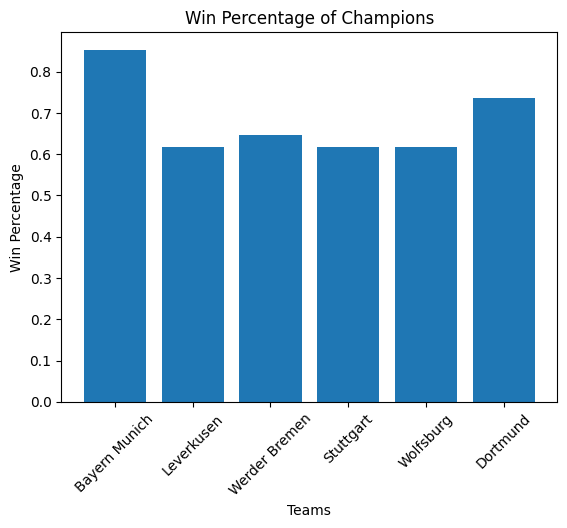

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_pandas = df_champions.toPandas()

plt.bar(df_pandas["Team"], df_pandas["WinPercentage"])

plt.title("Win Percentage of Champions")
plt.xlabel("Teams")
plt.ylabel("Win Percentage")

plt.xticks(rotation=45)
plt.show()


Text(0.5, 1.0, 'Nombre de records par équipe')

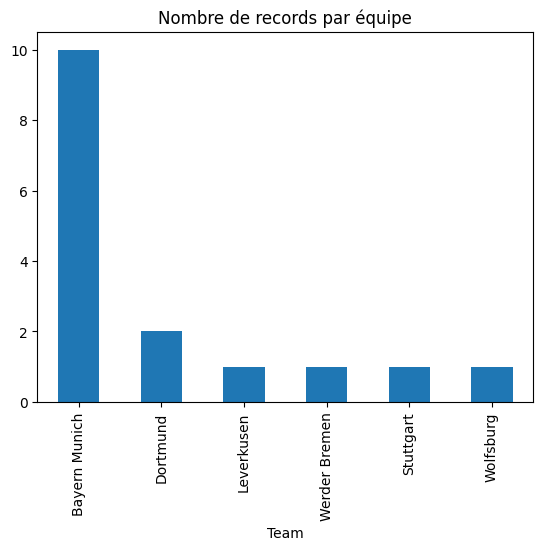

In [ ]:
df_pandas["Team"].value_counts().plot(kind="bar")
plt.title("Nombre de records par équipe")


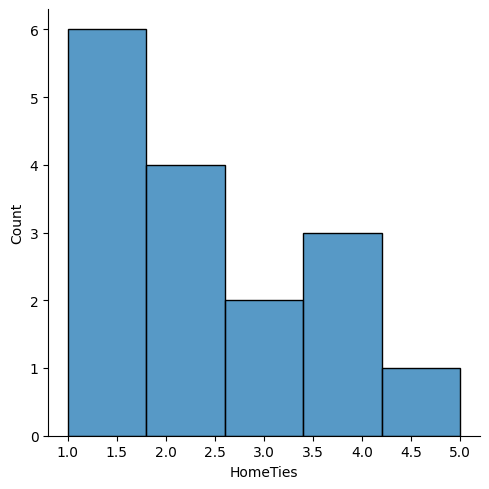

In [ ]:
df_pandas["HomeTies"].describe()
sns.displot(data=df_pandas, x="HomeTies")


<Axes: xlabel='Team', ylabel='HomeTies'>

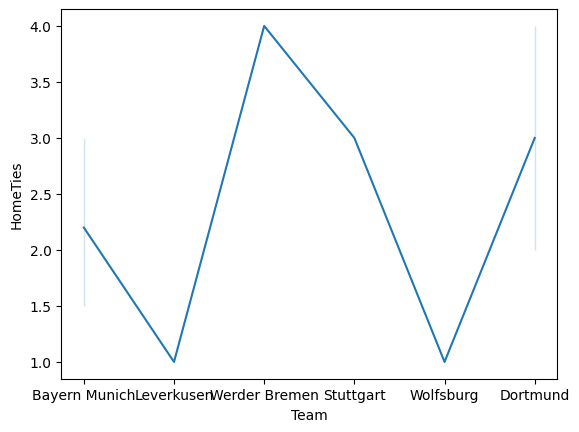

In [ ]:

df_pandas.groupby('Team')['HomeTies'].mean()
sns.lineplot(data=df_pandas, x="Team", y="HomeTies")

In [ ]:
from pyspark.sql import functions as F

# 1. نقوم بإنشاء عمود مؤقت يحمل نفس قيم Season لتتم عملية التقسيم بناءً عليه
df_to_save = df_ranked.withColumn("Season_Partition", F.col("Season"))

# 2. نقوم بالتقسيم باستخدام العمود المؤقت، وبذلك يتبقى عمود Season الأصلي داخل الملف
output_path_all = "processed_data/football_stats_partitioned"
df_to_save.write.mode("overwrite").partitionBy("Season_Partition").parquet(output_path_all)

In [ ]:
!zip -r football_parquet_files.zip processed_data/

# 2. استدعاء مكتبة Colab لتحميل الملف تلقائياً إلى حاسوبك
from google.colab import files
files.download('football_parquet_files.zip')

  adding: processed_data/ (stored 0%)
  adding: processed_data/football_top_teams/ (stored 0%)
  adding: processed_data/football_top_teams/_SUCCESS (stored 0%)
  adding: processed_data/football_top_teams/._SUCCESS.crc (stored 0%)
  adding: processed_data/football_top_teams/part-00000-1f185c4a-1ea6-411d-955e-cd74c56774a8-c000.snappy.parquet (deflated 66%)
  adding: processed_data/football_top_teams/.part-00000-1f185c4a-1ea6-411d-955e-cd74c56774a8-c000.snappy.parquet.crc (stored 0%)
  adding: processed_data/football_stats_partitioned/ (stored 0%)
  adding: processed_data/football_stats_partitioned/_SUCCESS (stored 0%)
  adding: processed_data/football_stats_partitioned/Season_Partition=2007/ (stored 0%)
  adding: processed_data/football_stats_partitioned/Season_Partition=2007/part-00000-efaeb47d-f261-415a-a87f-f7e9c70df44e.c000.snappy.parquet (deflated 64%)
  adding: processed_data/football_stats_partitioned/Season_Partition=2007/.part-00000-efaeb47d-f261-415a-a87f-f7e9c70df44e.c000.snap

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>